# SIADS 699 — Dota 2 Movement Feature Engineering

**Project:** Predicting Dota 2 Player Skill via Spatio-Temporal Movement Data

This notebook builds the **L1** (per-player, per-timestep) and **L2** (player-match) feature tables from the raw positions.

### Pipeline overview
1. Load data
2. Apply team-relative coordinate transform
3. Build death mask
4. Compute basic L1 features
5. Aggregate to L2 (player-match level)
6. Attach labels & metadata
7. Save results + quick inspection


Get Data

In [ ]:
from google.colab import auth; auth.authenticate_user()
!gsutil -m cp -r gs://siads699-dota/dataset/v1/ .

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://siads699-dota/dataset/v1/README.md...
Copying gs://siads699-dota/dataset/v1/matches.csv...
Copying gs://siads699-dota/dataset/v1/players.csv...
Copying gs://siads699-dota/dataset/v1/positions.parquet...
\ [4/4 files][ 67.2 MiB/ 67.2 MiB] 100% Done                                    
Operation completed over 4 objects/67.2 MiB.                                     


Setup

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# Optional plotting
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Libraries loaded")

Libraries loaded


## 1. Paths & Constants

In [ ]:
# Colab path (data downloaded to /content/v1/)
DATA_DIR = Path("/content/v1")                        # positions.parquet, players.csv, matches.csv
OUT_DIR  = Path("/content/features")                  # output location
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Fountain coordinates measured from the map (from README — do not change)
R = np.array([9515.0, 9975.0])      # Radiant fountain
D = np.array([23451.0, 22746.0])    # Dire fountain
AXIS = D - R
L = float(np.linalg.norm(AXIS))
U = AXIS / L                        # unit vector along the main axis
N = np.array([-U[1], U[0]])         # perpendicular (lateral)

DIRE_SLOTS = {128, 129, 130, 131, 132}

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR :", OUT_DIR)
print("Axis length L:", round(L, 1))

DATA_DIR: /content/v1
OUT_DIR : /content/features
Axis length L: 18902.7


## 2. Team-relative coordinate transform

Raw `x, y` cannot be used directly. Radiant spawns at low coordinates and Dire at high ones, so the same number means the opposite thing for the two teams. A model would learn which side you were on before it learns anything about skill.

We convert to:
- `own_depth`  : 0 = own fountain, 1 = enemy fountain
- `own_lateral`: signed distance from the mid diagonal (mirrored for Dire)


In [ ]:
def to_team_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Raw x,y → own_depth and own_lateral. MUST be run before any feature work."""
    v = df[["x", "y"]].to_numpy(dtype=np.float64) - R
    depth   = (v @ U) / L
    lateral = v @ N
    dire = df["player_slot"].isin(DIRE_SLOTS).to_numpy()

    out = df.copy()
    out["own_depth"]   = np.where(dire, 1.0 - depth, depth)
    out["own_lateral"] = np.where(dire, -lateral, lateral)
    return out

print("to_team_frame() defined")

to_team_frame() defined


## 3. Load data

In [ ]:
print("Loading metadata...")
players = pd.read_csv(DATA_DIR / "players.csv")
matches = pd.read_csv(DATA_DIR / "matches.csv")

print("Loading positions (large file)...")
positions = pd.read_parquet(DATA_DIR / "positions.parquet")

print(f"positions : {positions.shape}")
print(f"players   : {players.shape}")
print(f"matches   : {matches.shape}")
print(f"unique matches in positions: {positions['match_id'].nunique()}")
print(f"player_slot values: {sorted(positions['player_slot'].unique())}")

Loading metadata...
Loading positions (large file)...
positions : (7168360, 7)
players   : (5330, 8)
matches   : (533, 14)
unique matches in positions: 533
player_slot values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(128), np.int64(129), np.int64(130), np.int64(131), np.int64(132)]


In [ ]:
positions.head(3)

,match_id,tick,player,x,y,sec,player_slot
0,8912659439,3508,0,9663.906,9680.969,0.0,0
1,8912659439,3508,1,9643.000,9840.031,0.0,1
2,8912659439,3508,2,9489.031,9968.219,0.0,2


In [ ]:
players.head(3)

,match_id,player_slot,account_id,hero_id,leaver_status,rank_tier,is_anonymous,run_id
0,8912751052,0,1080684182,50,1,31.0,False,eu_500
1,8912751052,1,1145197233,101,0,NaN,False,eu_500
2,8912751052,2,1168044991,4,0,33.0,False,eu_500


In [ ]:
matches["run_id"].value_counts()

,count
run_id,
eu_500,427
holdout_100,100
smoke_eu,6


## 4. Validate the coordinate transform

We take one match and check that after the transform:
- Both teams start near `own_depth ≈ 0` at the beginning of the game
- The two teams look roughly symmetric


In [ ]:
# Pick a short match for quick visual check
sample_match_id = matches.loc[matches["duration_s"].between(1800, 2200), "match_id"].iloc[0]
print("Sample match_id:", sample_match_id)

pos_sample = positions[positions["match_id"] == str(sample_match_id)].copy()
pos_sample = to_team_frame(pos_sample)

print("\nown_depth range :", round(pos_sample["own_depth"].min(), 3), "→", round(pos_sample["own_depth"].max(), 3))
print("own_lateral range:", round(pos_sample["own_lateral"].min(), 1), "→", round(pos_sample["own_lateral"].max(), 1))

# Early-game depth by team
early = pos_sample[pos_sample["sec"] < 60]
print("\nMean own_depth in first 60s:")
print(early.groupby(early["player_slot"].isin(DIRE_SLOTS))["own_depth"].mean())

Sample match_id: 8912754142

own_depth range : -0.032 → 0.99
own_lateral range: -9946.3 → 9664.6

Mean own_depth in first 60s:
player_slot
False    0.255188
True     0.291925
Name: own_depth, dtype: float64


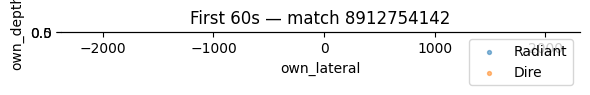

In [ ]:
# Optional: quick scatter of early positions in team frame
fig, ax = plt.subplots(figsize=(6, 6))
for is_dire, color, label in [(False, "C0", "Radiant"), (True, "C1", "Dire")]:
    mask = early["player_slot"].isin(DIRE_SLOTS) == is_dire
    ax.scatter(early.loc[mask, "own_lateral"], early.loc[mask, "own_depth"],
               s=8, alpha=0.5, c=color, label=label)
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("own_lateral")
ax.set_ylabel("own_depth")
ax.set_title(f"First 60s — match {sample_match_id}")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 5. Process one match → L2 features

We process match-by-match to keep memory usage low.

For each match we:
1. Apply the team-relative transform
2. Build a simple death mask (player teleports back near fountain)
3. Compute movement statistics only on live (non-dead) time
4. Aggregate to one row per player


In [ ]:
def assign_phase(sec: float) -> str:
    if sec < 600:
        return "laning"   # 0-10 min
    if sec < 1500:
        return "mid"      # 10-25 min
    return "late"


def process_one_match(pos: pd.DataFrame) -> pd.DataFrame:
    """
    Given positions for a single match, return one row per player_slot with L2 features.
    """
    pos = to_team_frame(pos)
    pos = pos.sort_values(["player_slot", "sec"])

    # --- death mask (simple heuristic) ---
    pos["prev_depth"] = pos.groupby("player_slot")["own_depth"].shift(1)
    pos["is_dead"] = (
        (pos["own_depth"] < 0.08) & (pos["prev_depth"] > 0.25)
    ).fillna(False)

    DEAD_WINDOW = 8.0  # seconds after detected death to keep masked
    pos["dead_mask"] = False
    for slot, grp in pos.groupby("player_slot"):
        dead_starts = grp.loc[grp["is_dead"], "sec"].values
        if len(dead_starts) == 0:
            continue
        secs = grp["sec"].values
        mask = np.zeros(len(grp), dtype=bool)
        for t0 in dead_starts:
            mask |= (secs >= t0) & (secs < t0 + DEAD_WINDOW)
        pos.loc[grp.index, "dead_mask"] = mask

    # --- movement features ---
    pos["dt"] = pos.groupby("player_slot")["sec"].diff().fillna(2.0)
    pos["dx"] = pos.groupby("player_slot")["own_depth"].diff()
    pos["dy"] = pos.groupby("player_slot")["own_lateral"].diff()
    pos["dist"] = np.sqrt(pos["dx"]**2 + pos["dy"]**2)
    pos["speed"] = pos["dist"] / pos["dt"].clip(lower=0.5)
    pos["is_idle"] = (pos["speed"] < 50) & (~pos["dead_mask"])

    # rough zone (can be improved with proper polygons later)
    pos["zone"] = pd.cut(
        pos["own_lateral"],
        bins=[-np.inf, -2000, 2000, np.inf],
        labels=["top", "mid", "bottom"]
    )
    pos["phase"] = pos["sec"].map(assign_phase)

    # only live rows for most stats
    live = pos.loc[~pos["dead_mask"]].copy()
    if live.empty:
        return pd.DataFrame()

    agg = live.groupby("player_slot").agg(
        n_samples        = ("sec", "count"),
        total_dist       = ("dist", "sum"),
        mean_speed       = ("speed", "mean"),
        median_speed     = ("speed", "median"),
        idle_share       = ("is_idle", "mean"),
        mean_depth       = ("own_depth", "mean"),
        median_depth     = ("own_depth", "median"),
        max_depth        = ("own_depth", "max"),
        depth_std        = ("own_depth", "std"),
        lateral_std      = ("own_lateral", "std"),
        mean_abs_lateral = ("own_lateral", lambda s: np.abs(s).mean()),
        first_sec        = ("sec", "min"),
        last_sec         = ("sec", "max"),
    ).reset_index()

    agg["duration"] = agg["last_sec"] - agg["first_sec"]
    agg["path_efficiency"] = agg["total_dist"] / agg["duration"].clip(lower=1.0)

    # zone × phase occupancy shares
    zp = (
        live.groupby(["player_slot", "zone", "phase"])
        .size()
        .unstack(level=["zone", "phase"], fill_value=0)
    )
    zp.columns = [f"share_{z}_{p}" for z, p in zp.columns]
    zp = zp.div(zp.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    zp = zp.reset_index()

    out = agg.merge(zp, on="player_slot", how="left")
    out["match_id"] = pos["match_id"].iloc[0]
    return out

print("process_one_match() defined")

process_one_match() defined


## 6. Build full L2 table

This loops over all 533 matches. It takes a couple of minutes.

In [ ]:
match_ids = positions["match_id"].unique()
print(f"{len(match_ids)} matches to process")

rows = []
for i, mid in enumerate(match_ids):
    if (i + 1) % 50 == 0 or i == 0:
        print(f"  processing match {i+1}/{len(match_ids)} ...")
    pos_m = positions[positions["match_id"] == mid]
    feat = process_one_match(pos_m)
    if not feat.empty:
        rows.append(feat)

print("Concatenating...")
l2 = pd.concat(rows, ignore_index=True)

# match_id is str in parquet, int in the CSVs
l2["match_id"] = l2["match_id"].astype(int)

print(f"L2 shape before joins: {l2.shape}")

533 matches to process
  processing match 1/533 ...


/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.

  processing match 50/533 ...


/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.

  processing match 100/533 ...


...

  processing match 450/533 ...


/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.

  processing match 500/533 ...


/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  live.groupby(["player_slot", "zone", "phase"])
/tmp/ipykernel_2103/1312216789.

Concatenating...
L2 shape before joins: (5330, 26)


## 7. Attach labels and match metadata

In [ ]:
l2 = l2.merge(
    players[["match_id", "player_slot", "account_id", "hero_id", "rank_tier", "leaver_status"]],
    on=["match_id", "player_slot"],
    how="left"
)
l2 = l2.merge(
    matches[["match_id", "skill_label", "avg_rank_tier", "region", "duration_s", "run_id"]],
    on="match_id",
    how="left"
)

print(f"Final L2 shape: {l2.shape}")
print(f"Players with rank_tier: {l2['rank_tier'].notna().sum()}")
l2.head()

Final L2 shape: (5330, 35)
Players with rank_tier: 4993


,player_slot,n_samples,total_dist,mean_speed,median_speed,idle_share,mean_depth,median_depth,max_depth,depth_std,lateral_std,mean_abs_lateral,first_sec,last_sec,duration,path_efficiency,share_top_laning,share_top_late,share_top_mid,share_mid_laning,share_mid_late,share_mid_mid,share_bottom_laning,share_bottom_late,share_bottom_mid,match_id,account_id,hero_id,rank_tier,leaver_status,skill_label,avg_rank_tier,region,duration_s,run_id
0,0,1333,334808.589957,125.678900,67.488151,0.448612,0.454697,0.465430,0.954529,0.179507,4340.529061,4935.283721,0.0,2696.0,2696.0,124.187162,0.220555,0.198050,0.267817,0.004501,0.126782,0.015754,0.000000,0.118530,0.048012,8912659439,134060134,8,51.0,0,high,NaN,EUROPE,NaN,smoke_eu
1,1,1301,323593.534126,124.459052,78.566569,0.438893,0.377465,0.356999,0.877218,0.172971,3785.880979,3442.952327,0.0,2696.0,2696.0,120.027275,0.000000,0.105304,0.059954,0.052267,0.230592,0.080707,0.172175,0.112221,0.186779,8912659439,881007835,101,NaN,0,high,NaN,EUROPE,NaN,smoke_eu
2,2,1313,271067.915856,103.303322,31.316668,0.552932,0.341938,0.345069,0.890217,0.194624,3882.821497,3361.461890,0.0,2696.0,2696.0,100.544479,0.000000,0.108911,0.037319,0.090632,0.225438,0.089871,0.134806,0.112719,0.200305,8912659439,1200502316,2,65.0,0,high,NaN,EUROPE,NaN,smoke_eu
3,3,1341,398394.452027,148.654646,68.137246,0.422073,0.398014,0.374695,0.941944,0.190963,3617.448954,2629.810511,0.0,2696.0,2696.0,147.772423,0.000000,0.201342,0.102163,0.220731,0.112603,0.179717,0.000000,0.132737,0.050708,8912659439,1247695448,74,52.0,0,high,NaN,EUROPE,NaN,smoke_eu
4,4,1325,310751.359796,117.353233,73.114410,0.427170,0.430820,0.435917,0.923141,0.185225,4383.392364,4287.167692,0.0,2696.0,2696.0,115.263857,0.218113,0.190189,0.165283,0.008302,0.172075,0.099623,0.000000,0.080755,0.065660,8912659439,471205509,27,51.0,0,high,NaN,EUROPE,NaN,smoke_eu


## 8. Quick inspection

In [ ]:
l2[["mean_depth", "idle_share", "path_efficiency", "rank_tier"]].describe()

,mean_depth,idle_share,path_efficiency,rank_tier
count,5330.000000,5330.000000,5330.000000,4993.000000
mean,0.445313,0.461389,117.663688,43.030843
std,0.094879,0.063443,19.418441,18.960502
min,0.211468,0.270073,49.647967,11.000000
25%,0.366343,0.419085,104.431105,25.000000
50%,0.446948,0.459186,116.353922,42.000000
75%,0.523386,0.500000,129.857480,55.000000
max,0.704682,0.832618,216.918944,80.000000


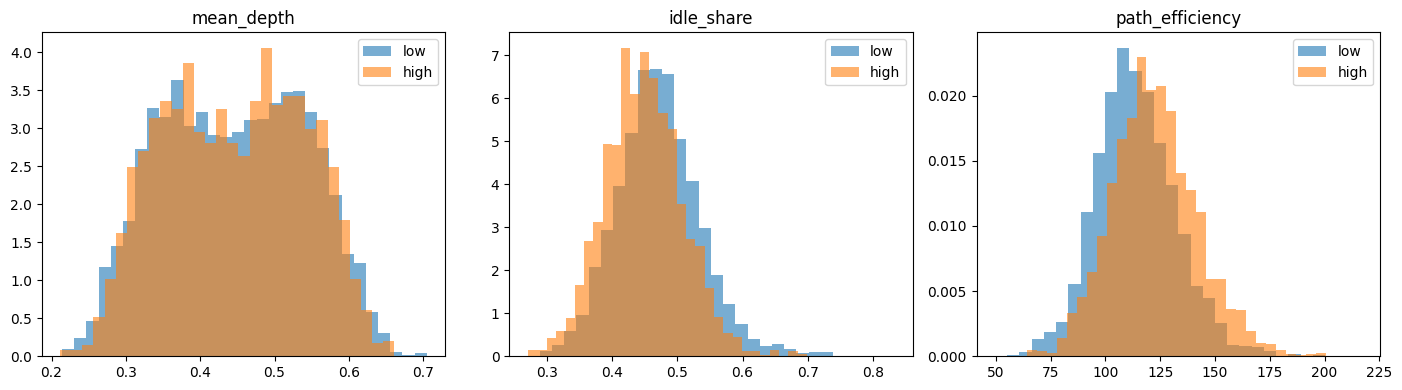

In [ ]:
# Distribution of key features by skill_label
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["mean_depth", "idle_share", "path_efficiency"]):
    for label, color in [("low", "C0"), ("high", "C1")]:
        subset = l2.loc[l2["skill_label"] == label, col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Correlation with rank_tier (simple check)
numeric_cols = ["mean_depth", "idle_share", "path_efficiency", "mean_speed",
                "depth_std", "lateral_std", "max_depth"]
print(l2[numeric_cols + ["rank_tier"]].corr()["rank_tier"].sort_values(ascending=False))

rank_tier          1.000000
mean_speed         0.240102
path_efficiency    0.239914
lateral_std        0.092374
max_depth          0.015464
mean_depth         0.014755
depth_std         -0.027343
idle_share        -0.184342
Name: rank_tier, dtype: float64


## 9. Save outputs

In [ ]:
l2_path_csv = OUT_DIR / "l2_player_match.csv"
l2_path_parquet = OUT_DIR / "l2_player_match.parquet"

l2.to_csv(l2_path_csv, index=False)
try:
    l2.to_parquet(l2_path_parquet, index=False)
    print(f"Saved parquet → {l2_path_parquet}")
except Exception as e:
    print(f"Parquet save failed ({e}), CSV is still available")

print(f"Saved CSV     → {l2_path_csv}")
print(f"Shape: {l2.shape}")

# small sample for quick looks
sample = l2.sample(min(30, len(l2)), random_state=42)
sample.to_csv(OUT_DIR / "l2_sample.csv", index=False)
print(f"Saved sample  → {OUT_DIR / 'l2_sample.csv'}")

Saved parquet → /content/features/l2_player_match.parquet
Saved CSV     → /content/features/l2_player_match.csv
Shape: (5330, 35)
Saved sample  → /content/features/l2_sample.csv


Libraries loaded for modeling.
Training set shape: (4264, 26)
Testing set shape: (1066, 26)
Training Baseline XGBoost Classifier...
Training complete.
------------------------------
Baseline Model Performance:
Accuracy: 0.7280
AUC:      0.7863
F1-Score: 0.6628
------------------------------

Classification Report:
              precision    recall  f1-score   support

   Low Skill       0.74      0.81      0.77       606
  High Skill       0.71      0.62      0.66       460

    accuracy                           0.73      1066
   macro avg       0.72      0.71      0.72      1066
weighted avg       0.73      0.73      0.72      1066

Generating SHAP values...


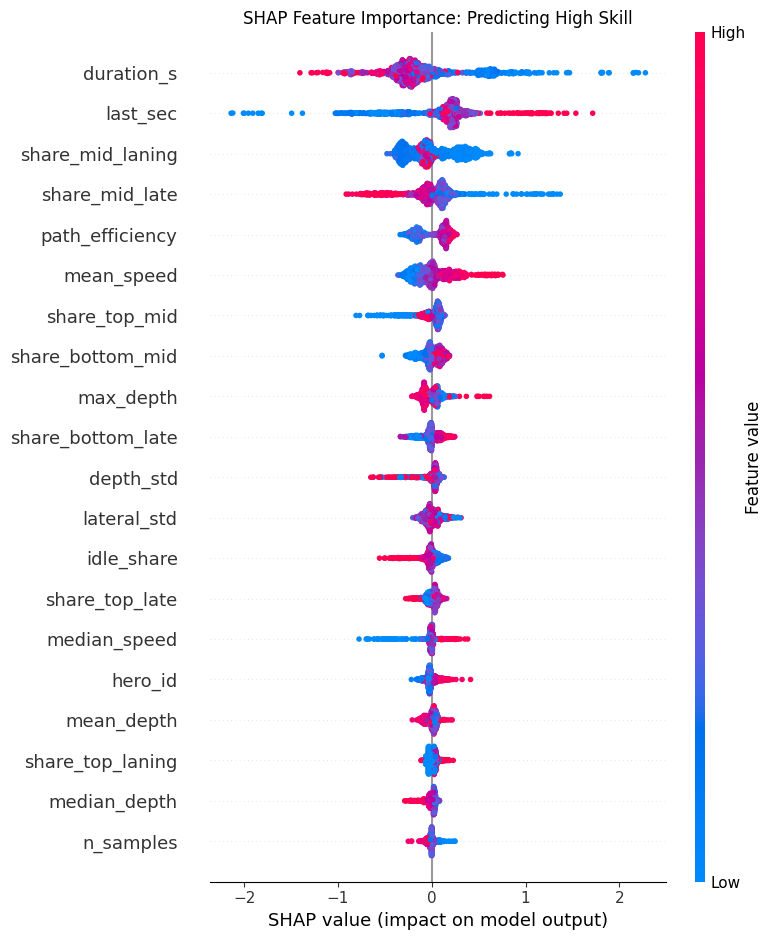

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
import matplotlib.pyplot as plt

print("Libraries loaded for modeling.")
# 1. Data Preparation
# Drop rows where the target label is missing
data = l2.dropna(subset=['skill_label']).copy()
# Map the target variable to binary (0 = low, 1 = high)
data['target'] = data['skill_label'].map({'low': 0, 'high': 1})
# Define the features to drop (identifiers, leaks, and string columns)
# Adjust this list if you added more metadata columns
# cols_to_drop = [
#     'match_id', 'player_slot', 'account_id', 'skill_label', 'run_id',
#     'target', 'region', 'leaver_status'
# ]
cols_to_drop = [
    'match_id', 'player_slot', 'account_id', 'skill_label', 'run_id',
    'target', 'region', 'leaver_status', 'avg_rank_tier', 'rank_tier'
]


# Separate features (X) and target (y)
X = data.drop(columns=[col for col in cols_to_drop if col in data.columns])
y = data['target']

# Handle any remaining NaNs in the feature set (XGBoost can handle NaNs,
# but it's often safer to fill them for baseline consistency)
X = X.fillna(X.median())

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# 2. Train the Baseline XGBoost Model
print("Training Baseline XGBoost Classifier...")
# Initialize model with basic parameters
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1
)
# Fit the model
xgb_model.fit(X_train, y_train)
print("Training complete.")

# 3. Evaluate Performance
# Generate predictions
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print("-" * 30)
print("Baseline Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC:      {auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 30)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Skill', 'High Skill']))

# 4. SHAP Feature Importance
print("Generating SHAP values...")
# Initialize the TreeExplainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot the SHAP summary (This will show up inline in Colab)
plt.title("SHAP Feature Importance: Predicting High Skill")
shap.summary_plot(shap_values, X_test, plot_type="dot")



In [ ]:
data.columns

Index(['player_slot', 'n_samples', 'total_dist', 'mean_speed', 'median_speed', 'idle_share', 'mean_depth',
       'median_depth', 'max_depth', 'depth_std', 'lateral_std', 'mean_abs_lateral', 'first_sec', 'last_sec',
       'duration', 'path_efficiency', 'share_top_laning', 'share_top_late', 'share_top_mid', 'share_mid_laning',
       'share_mid_late', 'share_mid_mid', 'share_bottom_laning', 'share_bottom_late', 'share_bottom_mid', 'match_id',
       'account_id', 'hero_id', 'rank_tier', 'leaver_status', 'skill_label', 'avg_rank_tier', 'region', 'duration_s',
       'run_id', 'target'],
      dtype='object')

In [ ]:
import itertools
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

print("Libraries loaded for optimization loop.")

# 0. 기본적으로 항상 제외해야 하는 컬럼들 (식별자 및 타겟)
base_cols_to_drop = [
    'match_id', 'player_slot', 'account_id', 'skill_label', 'run_id',
    'target', 'region', 'leaver_status', 'avg_rank_tier', 'rank_tier', 'hero_id'
]

# 실험해볼 추가 드롭 후보 컬럼들 (예시로 유력한 누출(Leak) 변수 및 메타데이터 지정)
# 원하시는 컬럼들로 자유롭게 수정 가능합니다.
experimental_cols = ['total_dist', 'mean_speed', 'median_speed', 'idle_share', 'mean_depth',
       'median_depth', 'max_depth', 'depth_std', 'lateral_std', 'mean_abs_lateral', 'first_sec', 'last_sec',
       'duration', 'path_efficiency', 'share_top_laning', 'share_top_late', 'share_top_mid', 'share_mid_laning',
       'share_mid_late', 'share_mid_mid', 'share_bottom_laning', 'share_bottom_late', 'share_bottom_mid', 'duration_s']

# 결과를 저장할 리스트
experiment_results = []

# 1부터 experimental_cols의 전체 길이까지 모든 조합 테스트 (필요에 따라 특정 조합만 지정 가능)
# 여기서는 조합의 수가 너무 많아지지 않도록 튜플 형태로 순회합니다.
for i in range(len(experimental_cols) + 1):
    for combo in itertools.combinations(experimental_cols, i):
        # 이번 실험에서 드롭할 최종 컬럼 목록
        current_cols_to_drop = base_cols_to_drop + list(combo)

        print(f"\n--- Testing with dropped columns: {current_cols_to_drop} ---")

        # 데이터 준비
        data = l2.dropna(subset=['skill_label']).copy()
        data['target'] = data['skill_label'].map({'low': 0, 'high': 1})

        # 피처(X)와 타겟(y) 분리
        X = data.drop(columns=[col for col in current_cols_to_drop if col in data.columns])
        y = data['target']

        # 결측치 채우기
        X = X.fillna(X.median())

        # 만약 드롭 후 피처가 비어있다면 스킵
        if X.shape[1] == 0:
            print("Skipped: No features left.")
            continue

        # Train-test 분할
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        # 모델 학습
        xgb_model = xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric='auc',
            random_state=42,
            n_estimators=100,
            max_depth=4,
            learning_rate=0.1
        )
        xgb_model.fit(X_train, y_train)

        # 평가
        y_pred = xgb_model.predict(X_test)
        y_proba = xgb_model.predict_proba(X_test)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)

        # 결과 기록
        experiment_results.append({
            'dropped_cols': current_cols_to_drop,
            'features_used_count': X.shape[1],
            'accuracy': accuracy,
            'auc': auc,
            'f1_score': f1
        })

# 2. 결과 종합 및 최적의 모델 선정
results_df = pd.DataFrame(experiment_results)

# AUC 또는 F1-Score 기준으로 정렬 (여기서는 AUC 기준 내림차순 정렬)
results_df = results_df.sort_values(by='auc', ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("TOP 5 EXPERIMENT RESULTS:")
print("="*50)
print(results_df.head(5).to_string())

# 최적의 드롭 컬럼 세트 추출
best_drop_cols = results_df.loc[0, 'dropped_cols']
print("\n" + "="*50)
print(f"Optimal cols_to_drop: {best_drop_cols}")
print(f"Best AUC Score: {results_df.loc[0, 'auc']:.4f}")
print("="*50)

Libraries loaded for optimization loop.

--- Testing with dropped columns: ['match_id', 'player_slot', 'account_id', 'skill_label', 'run_id', 'target', 'region', 'leaver_status', 'avg_rank_tier', 'rank_tier', 'hero_id'] ---

--- Testing with dropped columns: ['match_id', 'player_slot', 'account_id', 'skill_label', 'run_id', 'target', 'region', 'leaver_status', 'avg_rank_tier', 'rank_tier', 'hero_id', 'total_dist'] ---

--- Testing with dropped columns: ['match_id', 'player_slot', 'account_id', 'skill_label', 'run_id', 'target', 'region', 'leaver_status', 'avg_rank_tier', 'rank_tier', 'hero_id', 'mean_speed'] ---

--- Testing with dropped columns: ['match_id', 'player_slot', 'account_id', 'skill_label', 'run_id', 'target', 'region', 'leaver_status', 'avg_rank_tier', 'rank_tier', 'hero_id', 'median_speed'] ---

--- Testing with dropped columns: ['match_id', 'player_slot', 'account_id', 'skill_label', 'run_id', 'target', 'region', 'leaver_status', 'avg_rank_tier', 'rank_tier', 'hero_id', 

KeyboardInterrupt: 

Libraries loaded for modeling.
Training set shape: (4264, 26)
Testing set shape: (1066, 26)
Training Baseline XGBoost Classifier...
Training complete.
------------------------------
Baseline Model Performance:
Accuracy: 0.7280
AUC:      0.7863
F1-Score: 0.6628
------------------------------

Classification Report:
              precision    recall  f1-score   support

   Low Skill       0.74      0.81      0.77       606
  High Skill       0.71      0.62      0.66       460

    accuracy                           0.73      1066
   macro avg       0.72      0.71      0.72      1066
weighted avg       0.73      0.73      0.72      1066

Generating SHAP values...


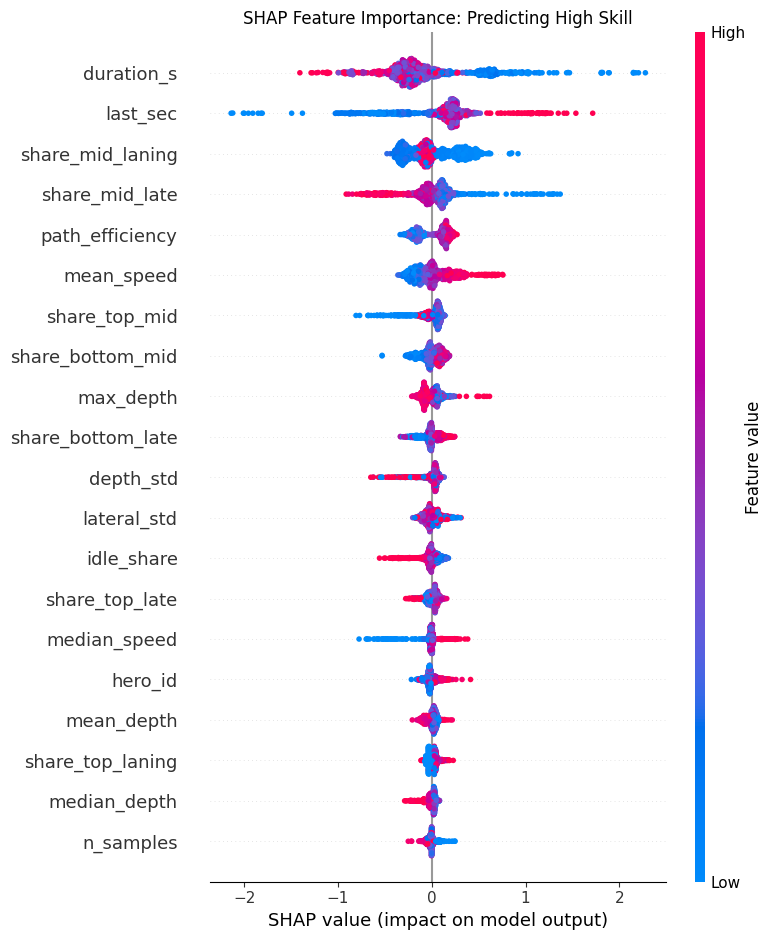

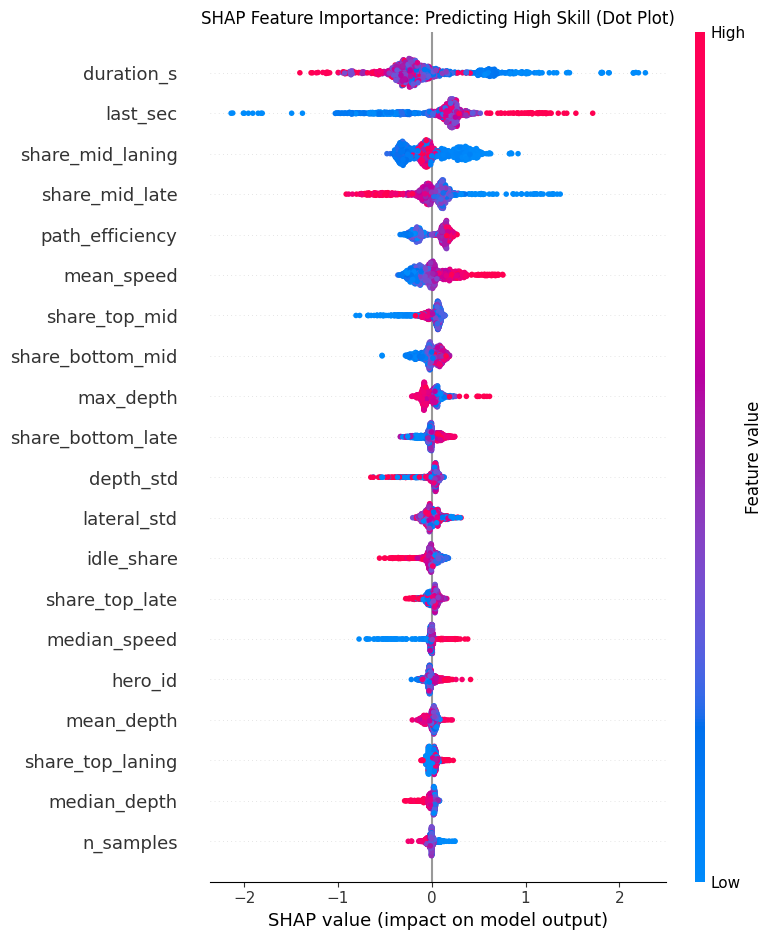

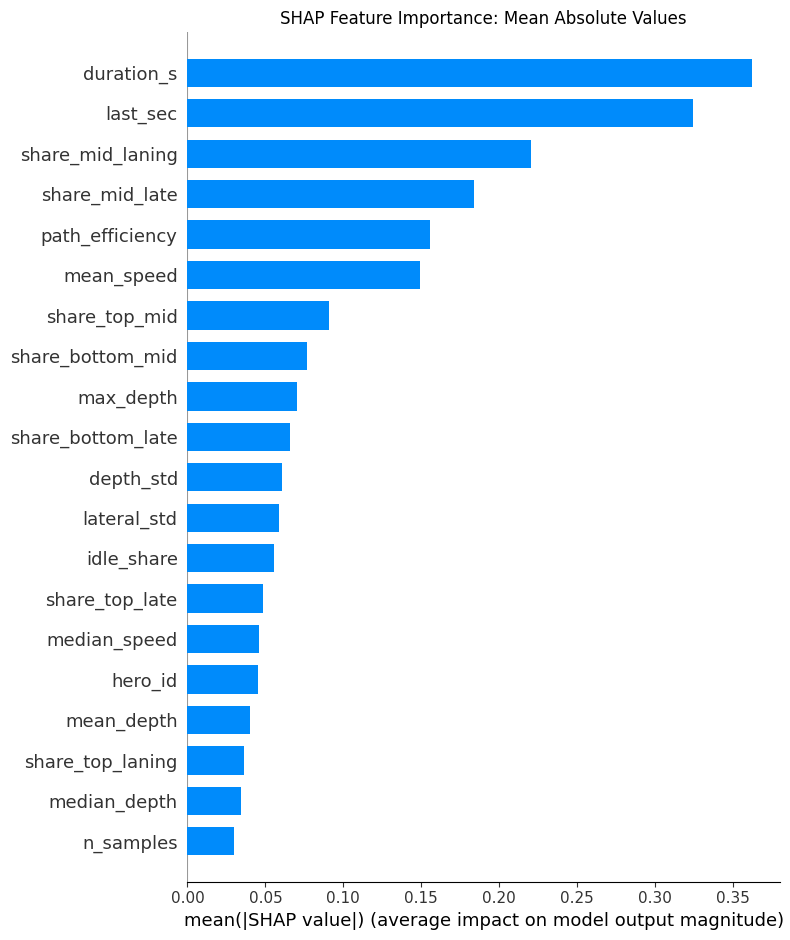

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
import matplotlib.pyplot as plt

print("Libraries loaded for modeling.")
# 1. Data Preparation
# Drop rows where the target label is missing
data = l2.dropna(subset=['skill_label']).copy()
# Map the target variable to binary (0 = low, 1 = high)
data['target'] = data['skill_label'].map({'low': 0, 'high': 1})
# Define the features to drop (identifiers, leaks, and string columns)
# Adjust this list if you added more metadata columns
# cols_to_drop = [
#     'match_id', 'player_slot', 'account_id', 'skill_label', 'run_id',
#     'target', 'region', 'leaver_status'
# ]
cols_to_drop = [
    'match_id', 'player_slot', 'account_id', 'skill_label', 'run_id',
    'target', 'region', 'leaver_status', 'avg_rank_tier', 'rank_tier'
]


# Separate features (X) and target (y)
X = data.drop(columns=[col for col in cols_to_drop if col in data.columns])
y = data['target']

# Handle any remaining NaNs in the feature set (XGBoost can handle NaNs,
# but it's often safer to fill them for baseline consistency)
X = X.fillna(X.median())

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# 2. Train the Baseline XGBoost Model
print("Training Baseline XGBoost Classifier...")
# Initialize model with basic parameters
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1
)
# Fit the model
xgb_model.fit(X_train, y_train)
print("Training complete.")

# 3. Evaluate Performance
# Generate predictions
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print("-" * 30)
print("Baseline Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC:      {auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 30)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Skill', 'High Skill']))

# 4. SHAP Feature Importance
print("Generating SHAP values...")
# Initialize the TreeExplainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot the SHAP summary (This will show up inline in Colab)
plt.title("SHAP Feature Importance: Predicting High Skill")
shap.summary_plot(shap_values, X_test, plot_type="dot")

plt.figure(figsize=(10, 6)) # 그래프 크기 조정 (선택 사항)
plt.title("SHAP Feature Importance: Predicting High Skill (Dot Plot)")
shap.summary_plot(shap_values, X_test, plot_type="dot", sort=True)

plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance: Mean Absolute Values")
shap.summary_plot(shap_values, X_test, plot_type="bar", sort=True)